#Simplifying Self-RAG:
It’s an advanced Retrieval-Augmented Generation (RAG) technique in which the model evaluates its own retrieved documents/information through self-reflection and self-grading before generating the final response.

In the official [paper](https://arxiv.org/abs/2310.11511) few decisions are made:
<br>

## Self-RAG Decision Framework

**1. Retrieval Decision Assessment**
- The system evaluates whether external knowledge retrieval is necessary
- Given a user query `x` (and potentially an existing response `y`), the system determines if consulting the retriever `R` would improve answer quality
- Decision outcomes: `retrieve`, `skip retrieval`, `continue with current information`

**2. Relevance Filtering of Retrieved Content**
- For each retrieved document chunk `d` from the collection `D`, the system assesses information utility
- The evaluation determines whether chunk `d` contains actionable information that addresses the core question `x`
- Classification results: `Yes`, `No`

**3. Factual Grounding Verification**
- The system cross-references each generated response `y` against its corresponding source chunk `d`
- This step identifies potential hallucinations by checking if all verifiable claims in the generation are actually supported by the source material
- Support levels: `fully supported`, `partially supported`, `no support`

**4. Response Quality Evaluation**
- The system assesses how well each generated answer `y` (derived from chunk `d`) actually addresses the original question `x`
- This measures the practical utility and completeness of the response from the user's perspective
- Quality ratings: `5` (excellent) to `1` (poor)

We'll implement these Self-RAG concepts using [LangGraph](https://langchain-ai.github.io/langgraph/), building everything from scratch.

####FLOW:


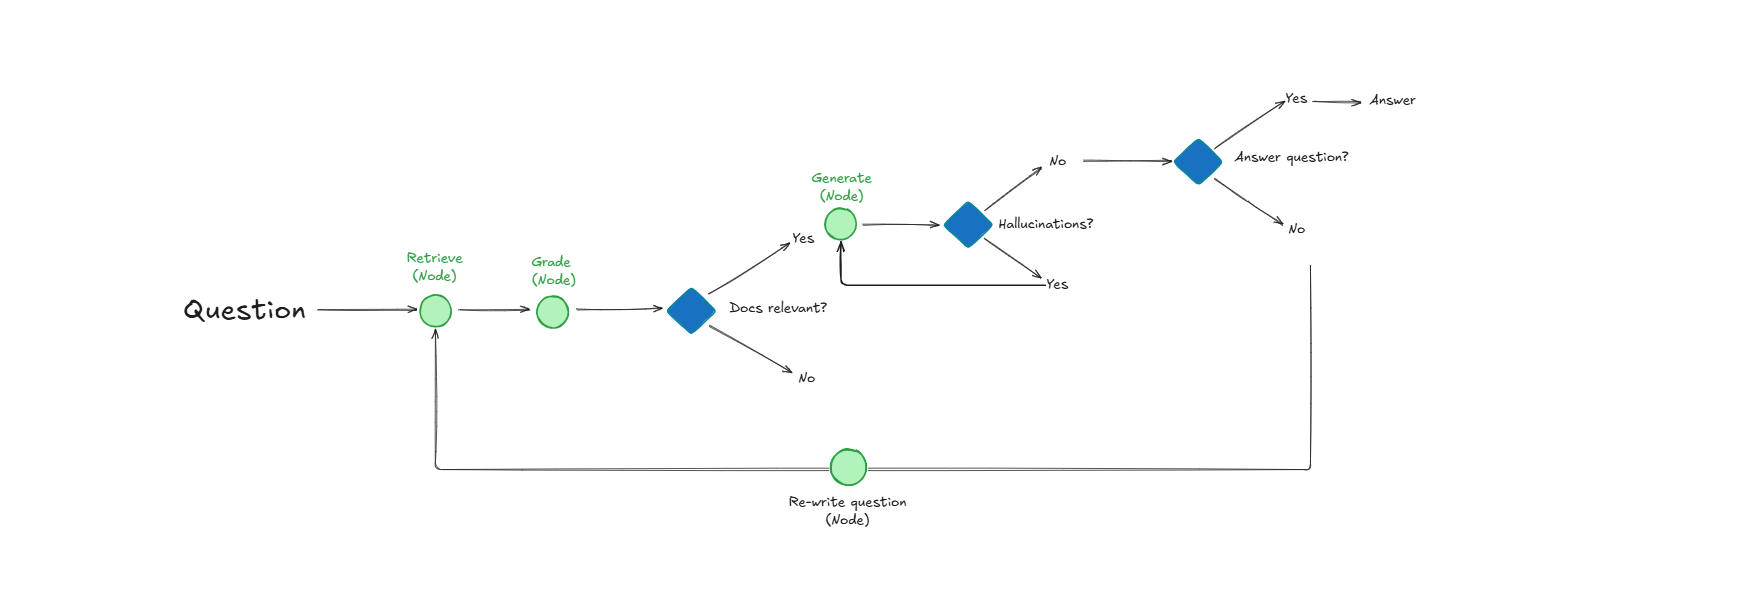

In [ ]:
# for snaps
from IPython.display import Image, display
display(Image("/content/Screenshot 2025-09-16 102819.png"))

##Enviornment setup:
(1) Install all the required dependencies

In [ ]:
! pip install -U langchain_community tiktoken langchain_groq langchainhub chromadb langchain langgraph

In [ ]:
# imports
# set the GROQ_API_KEY in your colab secrets then load into notebook by this code:
# Get API key from Colab secrets
import os
from google.colab import userdata

try:
    from google.colab import userdata
    os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
    print("GROQ API key loaded successfully!")
except Exception as e:
    print(f"Error loading API key: {e}")
    print("Please add your GROQ_API_KEY to Colab secrets (🔑 icon in left sidebar)")

GROQ API key loaded successfully!


In [ ]:
# Configuration
CHUNK_SIZE = 1000
CHUNK_OVERLAP = 200
MODEL_NAME = "meta-llama/llama-4-scout-17b-16e-instruct"  # Use a valid Groq model
TEMPERATURE = 0
EMBEDDING_MODEL = "all-MiniLM-L6-v2"

print(f"Configuration:")
print(f"- Model: {MODEL_NAME}")
print(f"- Temperature: {TEMPERATURE}")
print(f"- Chunk size: {CHUNK_SIZE}")
print(f"- Embedding model: {EMBEDDING_MODEL}")

Configuration:
- Model: meta-llama/llama-4-scout-17b-16e-instruct
- Temperature: 0
- Chunk size: 1000
- Embedding model: all-MiniLM-L6-v2


##Retriver component
lets index few of blog posts

In [ ]:
# imports
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_community.embeddings import SentenceTransformerEmbeddings
import warnings
warnings.filterwarnings('ignore')

####Data Loading and Vector Store Setup

In [ ]:
blog_urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

In [ ]:
print("Loading documents...")
try:
    # Load documents
    docs = []
    for url in blog_urls:
        print(f"Loading: {url}")
        loader = WebBaseLoader(url)
        docs.extend(loader.load())

    print(f"Loaded {len(docs)} documents")

    # Split documents
    text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP
    )
    doc_splits = text_splitter.split_documents(docs)
    print(f"Created {len(doc_splits)} document chunks")

    # Create vector store
    print("Creating vector store...")
    vectorstore = Chroma.from_documents(
        documents=doc_splits,
        collection_name="rag-chroma",
        embedding=SentenceTransformerEmbeddings(model_name=EMBEDDING_MODEL),
    )
    retriever = vectorstore.as_retriever()
    print("Vector store created successfully!")

except Exception as e:
    print(f"Error in data loading: {e}")

Loading documents...
Loading: https://lilianweng.github.io/posts/2023-06-23-agent/
Loading: https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/
Loading: https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/
Loaded 3 documents
Created 47 document chunks
Creating vector store...
Vector store created successfully!


###Define Pydantic Models for Structured Output




In [ ]:
### Retrieval Grader

# imports
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_groq import ChatGroq

# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

####Initialize LLMs and Chains

In [ ]:
# Initialize LLM
try:
    llm = ChatGroq(model=MODEL_NAME, temperature=TEMPERATURE)
    print(f"LLM initialized with model: {MODEL_NAME}")
    structured_llm_grader = llm.with_structured_output(GradeDocuments)
    print("Structured LLM grader created successfully!")
except Exception as e:
    print(f"Error initializing LLM: {e}")

LLM initialized with model: meta-llama/llama-4-scout-17b-16e-instruct
Structured LLM grader created successfully!


In [ ]:
# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

In [ ]:
# RAG Chain for Generation
try:
    # Create pipeline
    retrieval_grader = grade_prompt | structured_llm_grader
    question = "agent memory"

    # Retrieve docs safely
    docs = retriever.get_relevant_documents(question)
    if not docs:
        raise ValueError("No documents retrieved.")

    # Use first doc if available
    doc_txt = docs[0].page_content

    # Invoke the grader pipeline
    result = retrieval_grader.invoke({"question": question, "document": doc_txt})
    print(result)

except Exception as e:
    print(f"Error creating RAG chain: {e}")


binary_score='yes'


In [ ]:
### Generate

from langchain import hub
from langchain_core.output_parsers import StrOutputParser

# Prompt
prompt = hub.pull("rlm/rag-prompt")

# LLM
llm = ChatGroq(model_name=MODEL_NAME, temperature=TEMPERATURE)


# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

In a LLM-powered autonomous agent system, the agent's memory consists of two types: short-term memory, which utilizes in-context learning to learn, and long-term memory, which provides the agent with the capability to retain and recall infinite information over extended periods, often by leveraging an external vector store and fast retrieval. The long-term memory allows the agent to retain information over a long period. The agent uses these to improve performance.


In [ ]:
from re import TEMPLATE
### Hallucination Grader

# Data model
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatGroq(model= MODEL_NAME, temperature = TEMPERATURE)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# Prompt
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n
     Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""

hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"documents": docs, "generation": generation})

GradeHallucinations(binary_score='yes')

In [ ]:
### Answer Grader

# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatGroq(model=MODEL_NAME, temperature=TEMPERATURE)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question \n
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

GradeAnswer(binary_score='yes')

In [ ]:
### Question Re-writer

# LLM
llm = ChatGroq(model=MODEL_NAME)

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n
     for vectorstore retrieval. Look at the input and try to reason about the underlying sematic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Here is the initial question: \n\n {question} \n Formulate an improved question."),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser() | (lambda x: print(x))
question_rewriter.invoke({"question": question})

After analyzing the input question "agent memory", I've formulated an improved question that is optimized for vector store retrieval:

"What are the memory mechanisms and data storage strategies used by autonomous agents?"

This rephrased question aims to capture the underlying semantic intent of the original query by:

1. Adding more context: The term "autonomous agents" provides a clearer understanding of the type of agents being referred to.
2. Increasing specificity: The question now targets specific aspects of agent memory, namely "memory mechanisms" and "data storage strategies".
3. Using more descriptive language: The rephrased question incorporates more detailed and technical terms, making it easier for a vector store to match with relevant information.

This improved question should yield more accurate and relevant results when used for vector store retrieval.


##Graph:
Capture the flow in as a graph

##Graph State

In [ ]:
from typing import List
from typing_extensions import TypedDict


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """

    question: str
    generation: str
    documents: List[str]

In [ ]:
### Nodes


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]
    print(f"Question being retrieved: {question}") # Added print statement

    # Retrieval
    documents = retriever.get_relevant_documents(question)
    return {"documents": documents, "question": question}

In [ ]:
def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

In [ ]:
def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs, "question": question}

In [ ]:
def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}

In [ ]:
### Edges

def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    question = state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print("---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---")
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

In [ ]:
def grade_generation_v_documents_and_question(state):
    """
    Determines whether the generation is grounded in the document and answers question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score

    # Check hallucination
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        pprint("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

##Build Graph: <br>
Implementation of the workflow shown above.

In [ ]:
from langgraph.graph import END, StateGraph

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("retrieve", retrieve) # retrieve
workflow.add_node("grade_documents", grade_documents) # grade documents
workflow.add_node("generate", generate) # generatae
workflow.add_node("transform_query", transform_query) # transform_query

# Build graph
workflow.set_entry_point("retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "retrieve")
workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "transform_query",
    },
)

In [ ]:
# Compile
app = workflow.compile()

In [ ]:
from pprint import pprint

# Run
inputs = {"question": "Explain how the different types of agent memory work?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

---RETRIEVE---
Question being retrieved: Explain how the different types of agent memory work?
"Node 'retrieve':"
'\n---\n'
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
"Node 'grade_documents':"
'\n---\n'
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---
"Node 'generate':"
'\n---\n'
('In a LLM-powered autonomous agent system, there are two types of agent '
 'memory: short-term memory and long-term memory. Short-term memory utilizes '
 'in-context learning to learn, while long-term memory retains and recalls '
 'information over extended periods, often leveraging an external vector store '
 'and fast retrieval. Additionally, a "memory stream" is a long-term memory '
 "module that records a 

In [ ]:
inputs = {"question": "Explain how chain of thought prompting works?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

---RETRIEVE---
Question being retrieved: Explain how chain of thought prompting works?
"Node 'retrieve':"
'\n---\n'
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
"Node 'grade_documents':"
'\n---\n'
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---
"Node 'generate':"
'\n---\n'
('Chain of thought prompting works by instructing the model to "think step by '
 'step" to decompose hard tasks into smaller and simpler steps. This '
 'technique, known as Chain of Thought (CoT), utilizes more test-time '
 'computation to break down complex tasks into manageable tasks, shedding '
 "light on the model's thinking process. It has been extended to methods like "
 'Tree of Thoughts, which explores multiple